# Notebook 3 — Modello LSTM

Obiettivo: addestrare e valutare l'LSTM su tutti e 4 i sotto-dataset CMAPSS.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.models.lstm_model import build_lstm
from src.training import run_experiment
from src.metrics import evaluate

DATA_DIR = '../data/processed'
MODEL_DIR = '../saved_models'

## Perché questa architettura LSTM

L'LSTM è composto da due layer impilati (**stacked LSTM**), una scelta standard per le serie temporali industriali: il primo layer legge la sequenza grezza e produce un'uscita per ogni timestep (`return_sequences=True`), il secondo riceve questa sequenza e distilla una singola rappresentazione vettoriale dell'intera finestra.

**Perché 128 unità nel primo layer?**
128 è un punto di equilibrio tra capacità espressiva e rischio di overfitting per dataset di questa dimensione (~17k–54k campioni). Valori più alti (256) non portano miglioramenti significativi sul CMAPSS; valori più bassi (64) limitano la capacità di catturare pattern di degrado complessi.

**Perché 64 unità nel secondo layer?**
Il secondo LSTM ha metà delle unità del primo (128 → 64): è una scelta deliberata di **compressione gerarchica**. Il primo layer espande le feature temporali, il secondo le comprime in una rappresentazione densa. Dimezzare è una euristica consolidata in letteratura che riduce i parametri senza perdita di accuratezza.

**Perché dropout = 0.2?**
Il 20% di dropout dopo ogni LSTM è il valore di partenza standard per la regressione su serie temporali. Abbastanza da prevenire l'overfitting (confermato dalle curve train ≈ val), non abbastanza da rallentare eccessivamente la convergenza. Valori più alti (0.3+) aumentano il rumore nel gradiente.

**Perché MSE come loss?**
La loss MSE è coerente con RMSE come metrica di valutazione: minimizzare MSE equivale a minimizzare RMSE. La penalizzazione quadratica spinge il modello a evitare errori grandi, che nel contesto RUL corrispondono a predizioni molto lontane dal guasto reale.

**Callbacks:** `EarlyStopping(patience=15)` ferma il training se la val_loss non migliora per 15 epoche consecutive — spiega perché i dataset più grandi convergono in meno epoche (più campioni = aggiornamenti più stabili). `ReduceLROnPlateau` dimezza il learning rate dopo 7 epoche stagnanti, producendo la caratteristica curva "a gradino" visibile nei plot.

In [3]:
results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    # Carico gli array preprocessati salvati dal notebook 02
    X_train = np.load(f'{DATA_DIR}/X_train_{fd}.npy')
    y_train = np.load(f'{DATA_DIR}/y_train_{fd}.npy')
    X_test  = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test  = np.load(f'{DATA_DIR}/y_test_{fd}.npy')

    # window_size e n_features estratti dinamicamente → il modello si adatta ai dati
    window_size = X_train.shape[1]  # 30
    n_features  = X_train.shape[2]  # 17

    # Costruisco il modello: units=128 (primo LSTM), dropout=0.2
    model = build_lstm(window_size, n_features, units=128, dropout=0.2)
    model_path = f'{MODEL_DIR}/lstm_{fd}.keras'

    # run_experiment: train → salva best checkpoint → carica best model → valuta su test
    res = run_experiment(model, X_train, y_train, X_test, y_test, model_path)
    results[fd] = res
    print(f'{fd}: {res["metrics"]}')

2026-05-23 11:19:22.869192: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-23 11:19:22.869216: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-23 11:19:22.869221: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-23 11:19:22.869234: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-23 11:19:22.869243: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/200


2026-05-23 11:19:24.045351: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 5384.5986 - mae: 62.5617 - val_loss: 3416.5181 - val_mae: 50.8723 - learning_rate: 0.0010
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 2137.7043 - mae: 40.5377 - val_loss: 1827.3982 - val_mae: 38.6597 - learning_rate: 0.0010
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1763.0370 - mae: 37.1339 - val_loss: 1798.2114 - val_mae: 38.1955 - learning_rate: 0.0010
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1760.4669 - mae: 37.1491 - val_loss: 1802.5465 - val_mae: 38.2760 - learning_rate: 0.0010
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1756.4747 - mae: 37.0880 - val_loss: 1798.7061 - val_mae: 38.2116 - learning_rate: 0.0010
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1751.8147 - mae: 37.0374 - val_loss: 1797.7284 - val_mae: 38.2136 - learning_rate: 0.0010
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1721.6838 - mae: 36.8109 - val_loss: 1690.8424 - val

## Analisi delle curve di training

Le curve LSTM mostrano una struttura caratteristica **a gradino**:
1. Discesa rapida nelle prime epoche (apprendimento delle statistiche di base)
2. Plateau intermedio (la rete è "bloccata" in un minimo locale)
3. Seconda discesa brusca quando `ReduceLROnPlateau` abbassa il learning rate

**Train ≈ Val** in tutti i dataset: nessun overfitting, la regularizzazione (dropout + early stopping) funziona.

Il numero di epoche varia tra dataset:
- FD001/FD003 (~85-90 epoche): dataset più piccoli, convergenza più lenta
- FD002/FD004 (~45-75 epoche): più campioni per batch → aggiornamenti più stabili, convergenza più rapida

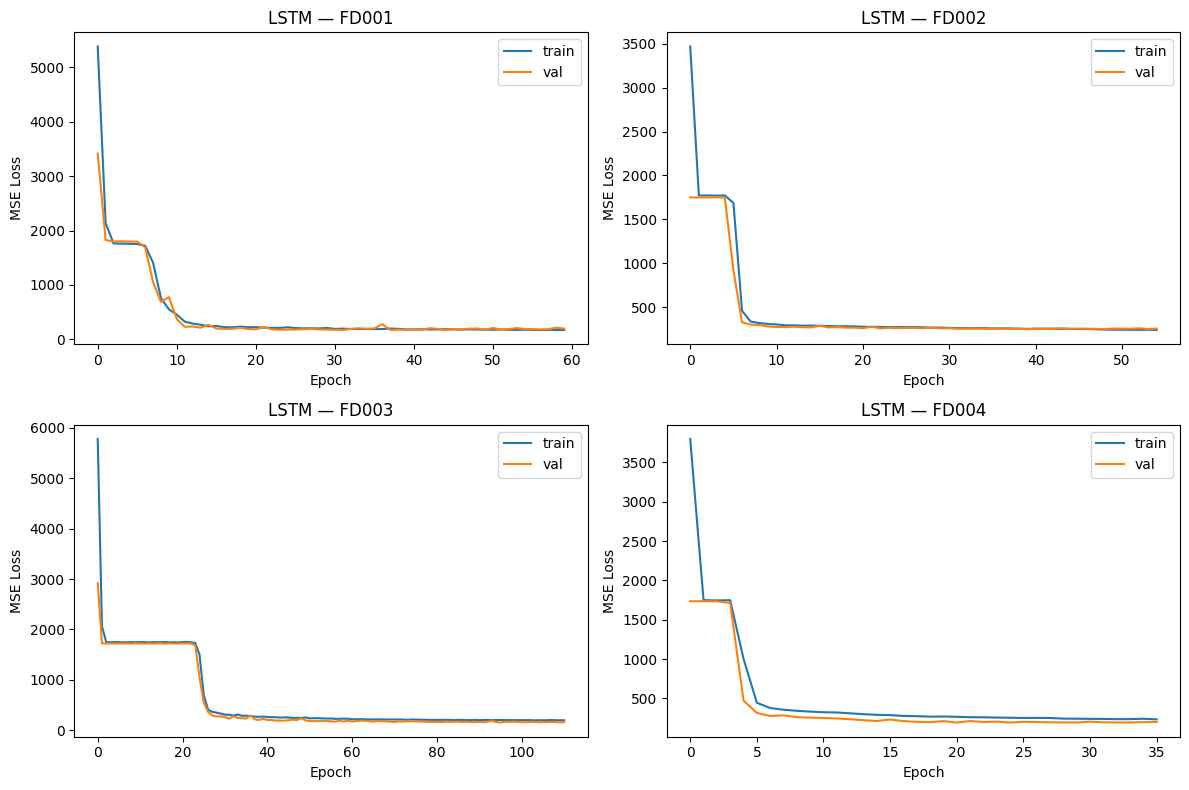

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (fd, res) in zip(axes.flatten(), results.items()):
    ax.plot(res['history']['loss'], label='train')
    ax.plot(res['history']['val_loss'], label='val')
    ax.set_title(f'LSTM — {fd}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    # Se train e val si sovrappongono → no overfitting (buon segnale)
    ax.legend()
plt.tight_layout()
plt.savefig('../plots/03_lstm_training_curves.png', dpi=150)
plt.show()